## UMAP Dimensionality Ablation: Justifying n_components=5

Empirically justifies the choice of `UMAP_N_COMPONENTS=5` used in the BERTopic notebook, rather than citing it as a library default. Sweeps `n_components` in {2, 5, 10, 15, 20}, for each value fits UMAP on the full-dimensional embeddings, then reports two metrics side by side: trustworthiness (how faithfully the reduced space preserves the original high-dimensional neighborhood structure) and silhouette score on the resulting HDBSCAN clusters (how well the reduced space actually supports the downstream clustering task it's used for).

**Why not a correlation-based feature selection approach instead**: a correlation heatmap and threshold makes sense for raw, human-interpretable features (paper length, citation count, publication year), where a high correlation between two columns has a clear meaning ("these two measure almost the same thing, drop one"). Text embedding dimensions are not that. Each of the 1536/3072 dimensions is a direction learned by a neural network during training, with no individual human-nameable meaning, semantic content lives in the combination of all dimensions together, not in any single one. Computing pairwise correlation between embedding dimensions and thresholding to keep 5 of them would discard 1531+ dimensions based on a criterion (linear correlation between individual coordinates) that has no established connection to preserving semantic structure. This is not a defensible feature-selection method for neural embeddings, and could plausibly produce a worse reduced space than UMAP, not a better-justified one.

**What UMAP actually does, for the methodology section**: UMAP does not select or exclude dimensions. It learns a new low-dimensional space that best preserves the *local neighborhood structure* of the original high-dimensional space, under the assumption that high-dimensional embeddings lie near a lower-dimensional manifold even though expressed in many raw coordinates. Concretely: for each point, UMAP builds a nearest-neighbor graph in the original space (governed by `n_neighbors`), then optimizes a low-dimensional layout (governed by `n_components`) so that the same points remain each other's nearest neighbors as closely as possible, subject to a minimum-distance packing constraint (`min_dist`). The basis for the reduction is neighborhood-graph preservation, not per-dimension exclusion.

**Why this ablation answers the actual question**: instead of asserting n_components=5 is reasonable, this notebook measures, for this specific corpus and embedding model, how much local structure is preserved (trustworthiness) and how well the reduction supports the actual downstream task (HDBSCAN clustering quality) at each candidate dimensionality. The chosen value can then be justified as "the smallest n_components where both metrics plateau" or similar, an empirical, corpus-specific justification rather than a borrowed default.

### Install dependencies (Colab only, skip if already installed locally)

In [ ]:
# Uncomment if running in Colab or a fresh environment
# !pip install umap-learn hdbscan scikit-learn huggingface_hub matplotlib pandas -q

### Configuration

In [1]:
import os

# --- Hugging Face repo (shared corpus) ---
REPO_ID = "Sakhiur/empirical-rag-paradigm-benchmark"
REPO_TYPE = "dataset"

# --- Which model's embeddings to use ---
EMBEDDING_MODEL = "text-embedding-3-small"

# --- Categories to run the ablation on ---
# Running on a few representative categories (not all 10) keeps this fast to iterate on;
# extend to ALL_CATEGORIES once you're satisfied with the approach on a subset.
ABLATION_CATEGORIES = ["cs.AI", "cs.LG", "cs.IR", "cs.DB", "cs.SE"]
CORPUS_TYPE = "abstracts"  # 'abstracts' or 'pdf_chunks'

# --- UMAP settings held constant across the sweep, only n_components varies ---
N_COMPONENTS_VALUES = [2, 5, 10, 15, 20]
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.0   # matches the BERTopic clustering UMAP setting, kept identical so this
                       # ablation reflects the same reduction the clustering notebook actually uses
RANDOM_STATE = 42

# --- HDBSCAN settings, matching the BERTopic notebook exactly ---
HDBSCAN_MIN_CLUSTER_SIZE = 10

# --- Trustworthiness settings ---
TRUSTWORTHINESS_N_NEIGHBORS = 15   # neighborhood size for the trustworthiness metric itself,
                                    # kept equal to UMAP_N_NEIGHBORS so the metric evaluates
                                    # preservation at the same neighborhood scale UMAP was optimizing for

# --- Visualization settings ---
IEEE_COLUMN_WIDTH_INCHES = 3.5
IEEE_FIGURE_DPI = 300

# --- Local paths ---
PROJECT_ROOT = ".."
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results", "umap_ablation")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "results", "figures")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

### Authenticate with Hugging Face

In [2]:
from huggingface_hub import whoami, login

try:
    user_info = whoami()
    print(f"Authenticated as: {user_info['name']}")
except Exception:
    print("Not authenticated yet, prompting for token...")
    login()
    user_info = whoami()
    print(f"Authenticated as: {user_info['name']}")

c:\project\empirical-rag-paradigm-benchmark\benchmarking-research\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Authenticated as: Sakhiur


### Loader function

In [4]:
import json
import numpy as np
from huggingface_hub import hf_hub_download


def load_embeddings(category: str, corpus_type: str) -> np.ndarray:
    repo_path = f"embeddings/{EMBEDDING_MODEL}/{corpus_type}/{category}.jsonl"
    try:
        local_path = hf_hub_download(repo_id=REPO_ID, repo_type=REPO_TYPE, filename=repo_path)
    except Exception as e:
        print(f"  [SKIP] {repo_path} not found on Hub ({e})")
        return np.array([])

    vectors = []
    with open(local_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            record = json.loads(line)
            vectors.append(record["embedding"])
    return np.array(vectors, dtype=np.float32)

### Ablation function

**Trustworthiness, what it measures and why it's the right metric here**: `sklearn.manifold.trustworthiness` compares each point's k-nearest-neighbors in the original high-dimensional space against its k-nearest-neighbors in the reduced space, and penalizes points that become "false neighbors" only after reduction (points that look close in the low-dimensional space but weren't actually close originally). It's bounded in [0, 1], where 1 means perfect neighborhood preservation. This directly measures the thing UMAP claims to do (preserve local structure), making it the natural metric for "how much did we lose by going from 1536D to nD," as opposed to a generic reconstruction-error metric that doesn't specifically target neighborhood fidelity.

**Why compute trustworthiness against the original embeddings, not against a fixed 2D reference**: the point of this metric is to answer "how much of the *original* structure survives at this n_components," so the comparison must be original-space vs reduced-space, not reduced-space vs another reduced-space. Comparing against a 2D reference would just measure agreement between two lossy projections, not fidelity to the source data.

**Why silhouette score is computed on HDBSCAN output specifically, not on the reduced embeddings directly**: silhouette score needs cluster labels to evaluate. Since the whole point of choosing n_components is to support the BERTopic/HDBSCAN clustering step, scoring the labels that step actually produces (rather than some other arbitrary clustering) keeps the ablation directly tied to the real downstream task, not a proxy for it. Noise points (label -1) are excluded from the silhouette calculation, consistent with how HDBSCAN results were scored in the earlier clustering notebook.

In [5]:
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score


def run_ablation_for_category(vectors: np.ndarray, category: str) -> list[dict]:
    """
    Runs the n_components sweep for one category's embeddings.
    Returns a list of result dicts, one per n_components value tested.
    """
    results = []

    for n_components in N_COMPONENTS_VALUES:
        print(f"    n_components={n_components}...")

        reducer = UMAP(
            n_neighbors=UMAP_N_NEIGHBORS,
            n_components=n_components,
            min_dist=UMAP_MIN_DIST,
            metric="cosine",
            random_state=RANDOM_STATE,
        )
        reduced = reducer.fit_transform(vectors)

        trust_score = trustworthiness(
            vectors, reduced, n_neighbors=TRUSTWORTHINESS_N_NEIGHBORS, metric="cosine"
        )

        clusterer = HDBSCAN(
            min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
            metric="euclidean",
            cluster_selection_method="eom",
        )
        labels = clusterer.fit_predict(reduced)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int(np.sum(labels == -1))

        sil_score = None
        if n_clusters >= 2:
            non_noise = labels != -1
            if non_noise.sum() >= 2 and len(set(labels[non_noise])) >= 2:
                sil_score = silhouette_score(reduced[non_noise], labels[non_noise], metric="euclidean")

        results.append({
            "category": category,
            "n_components": n_components,
            "trustworthiness": trust_score,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_pct": 100 * n_noise / len(labels),
            "silhouette": sil_score,
        })

        sil_display = f"{sil_score:.4f}" if sil_score is not None else "n/a"
        print(f"      trustworthiness={trust_score:.4f}, clusters={n_clusters}, noise={n_noise}/{len(labels)}, silhouette={sil_display}")

    return results

### Run the ablation

This is the slowest cell in the notebook: it fits a fresh UMAP model and runs HDBSCAN for every (category, n_components) combination, `len(ABLATION_CATEGORIES) x len(N_COMPONENTS_VALUES)` total fits. Expected to take a while, this is a one-time diagnostic run, not something re-run routinely.

In [6]:
all_ablation_results = []

for category in ABLATION_CATEGORIES:
    print(f"\n=== {category} ({CORPUS_TYPE}) ===")
    vectors = load_embeddings(category, CORPUS_TYPE)

    if vectors.size == 0:
        print(f"  [SKIP] no embeddings found")
        continue

    print(f"  {vectors.shape[0]} documents, dim={vectors.shape[1]}")
    category_results = run_ablation_for_category(vectors, category)
    all_ablation_results.extend(category_results)


=== cs.AI (abstracts) ===


c:\project\empirical-rag-paradigm-benchmark\benchmarking-research\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sakhiur\.cache\huggingface\hub\datasets--Sakhiur--empirical-rag-paradigm-benchmark. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


  7369 documents, dim=1536
    n_components=2...


c:\project\empirical-rag-paradigm-benchmark\benchmarking-research\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


      trustworthiness=0.9101, clusters=122, noise=2369/7369, silhouette=0.5499
    n_components=5...


...

      trustworthiness=0.9315, clusters=55, noise=794/2281, silhouette=0.6388
    n_components=15...


c:\project\empirical-rag-paradigm-benchmark\benchmarking-research\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


      trustworthiness=0.9305, clusters=52, noise=749/2281, silhouette=0.6057
    n_components=20...


c:\project\empirical-rag-paradigm-benchmark\benchmarking-research\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


      trustworthiness=0.9297, clusters=53, noise=780/2281, silhouette=0.6336


### Save results to CSV

One row per (category, n_components) combination. This CSV is the direct evidence artifact, it's what you'd point your supervisor to: not "BERTopic did it internally" but "here are the trustworthiness and silhouette scores we measured at five different dimensionalities, and here's why 5 was chosen."

In [7]:
import pandas as pd

df = pd.DataFrame(all_ablation_results)
csv_path = os.path.join(RESULTS_DIR, f"umap_ncomponents_ablation_{CORPUS_TYPE}_{EMBEDDING_MODEL}.csv")
df.to_csv(csv_path, index=False)
print(f"Saved {csv_path}")
df

Saved ..\results\umap_ablation\umap_ncomponents_ablation_abstracts_text-embedding-3-small.csv


,category,n_components,trustworthiness,n_clusters,n_noise,noise_pct,silhouette
0,cs.AI,2,0.910127,122,2369,32.148188,0.549863
1,cs.AI,5,0.952220,130,3081,41.810286,0.635729
2,cs.AI,10,0.953267,122,2932,39.788302,0.624555
3,cs.AI,15,0.953161,123,2794,37.915592,0.598910
4,cs.AI,20,0.953705,119,2812,38.159859,0.606696
5,cs.LG,2,0.926019,159,3057,28.447795,0.590669
6,cs.LG,5,0.962027,153,3550,33.035548,0.629418
7,cs.LG,10,0.964406,149,3651,33.975433,0.633899
8,cs.LG,15,0.964886,154,3414,31.769961,0.629130
9,cs.LG,20,0.964626,159,3619,33.677647,0.635868


### Aggregate across categories

Averages both metrics across categories for each n_components value, giving one summary curve rather than five separate per-category curves to eyeball at once. Individual per-category rows remain in the CSV above for anyone who wants to check whether the pattern holds category by category, not just on average.

In [8]:
agg_df = df.groupby("n_components").agg(
    mean_trustworthiness=("trustworthiness", "mean"),
    mean_silhouette=("silhouette", "mean"),
    mean_noise_pct=("noise_pct", "mean"),
    mean_n_clusters=("n_clusters", "mean"),
).reset_index()

agg_csv_path = os.path.join(RESULTS_DIR, f"umap_ncomponents_ablation_aggregated_{CORPUS_TYPE}_{EMBEDDING_MODEL}.csv")
agg_df.to_csv(agg_csv_path, index=False)
print(f"Saved {agg_csv_path}")
agg_df

Saved ..\results\umap_ablation\umap_ncomponents_ablation_aggregated_abstracts_text-embedding-3-small.csv


,n_components,mean_trustworthiness,mean_silhouette,mean_noise_pct,mean_n_clusters
0,2,0.906435,0.599455,30.890837,84.8
1,5,0.939841,0.630957,35.299595,84.0
2,10,0.942677,0.620749,36.294746,82.6
3,15,0.942552,0.598540,34.032181,81.2
4,20,0.942454,0.618421,35.725632,83.2


### Plot: trustworthiness and silhouette vs n_components

**Why a dual-axis line plot, not two separate figures**: the whole argument for choosing a specific n_components rests on seeing both metrics together, where the tradeoff (or lack of one) becomes visible. Trustworthiness typically increases monotonically with n_components (more dimensions retained means less information lost, by construction), while silhouette on the downstream clustering can behave non-monotonically (very high dimensionality can start reintroducing the curse-of-dimensionality problem that motivated this whole exercise). Showing both on one plot lets you point to the specific n_components where trustworthiness has mostly plateaued (diminishing returns from adding more dimensions) while silhouette is still strong, which is the actual empirical argument for "5 was a reasonable choice," or, just as usefully, reveals if 5 was NOT the best choice and something else should be used instead.

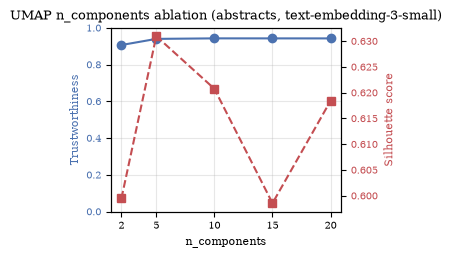

Saved ..\results\figures\umap_ncomponents_ablation_abstracts_text-embedding-3-small.png


In [9]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 8,
    "font.family": "serif",
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})

fig, ax1 = plt.subplots(figsize=(IEEE_COLUMN_WIDTH_INCHES, IEEE_COLUMN_WIDTH_INCHES * 0.75))

color1 = "#4C72B0"
ax1.set_xlabel("n_components")
ax1.set_ylabel("Trustworthiness", color=color1)
ax1.plot(agg_df["n_components"], agg_df["mean_trustworthiness"], marker="o", color=color1, label="Trustworthiness")
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
color2 = "#C44E52"
ax2.set_ylabel("Silhouette score", color=color2)
ax2.plot(agg_df["n_components"], agg_df["mean_silhouette"], marker="s", color=color2, linestyle="--", label="Silhouette")
ax2.tick_params(axis="y", labelcolor=color2)

ax1.set_xticks(N_COMPONENTS_VALUES)
ax1.set_title(f"UMAP n_components ablation ({CORPUS_TYPE}, {EMBEDDING_MODEL})")
ax1.grid(alpha=0.3)

fig.tight_layout()

plot_path = os.path.join(FIGURES_DIR, f"umap_ncomponents_ablation_{CORPUS_TYPE}_{EMBEDDING_MODEL}.png")
fig.savefig(plot_path, dpi=IEEE_FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Saved {plot_path}")

### Upload ablation results back to Hugging Face

In [10]:
from huggingface_hub import HfApi

api = HfApi()

for local_path, fname in [
    (csv_path, os.path.basename(csv_path)),
    (agg_csv_path, os.path.basename(agg_csv_path)),
]:
    repo_path = f"umap_ablation/{fname}"
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=repo_path,
        repo_id=REPO_ID,
        repo_type=REPO_TYPE,
        commit_message=f"Upload UMAP n_components ablation results (by {user_info['name']})",
    )
    print(f"Uploaded {repo_path}")

Uploaded umap_ablation/umap_ncomponents_ablation_abstracts_text-embedding-3-small.csv
Uploaded umap_ablation/umap_ncomponents_ablation_aggregated_abstracts_text-embedding-3-small.csv


### Reading the result

Look at `agg_df` and the plot above:

- If trustworthiness is already high (close to 1.0) by n_components=5 and only marginally improves at 10/15/20, that's the empirical case for diminishing returns beyond 5, more dimensions cost clustering quality and computation without meaningfully improving structure preservation.
- If silhouette score is highest (or close to the best) at n_components=5, that directly supports 5 as a good choice for the downstream clustering task specifically, not just "reasonably faithful" in the abstract.
- If either metric tells a different story (e.g. silhouette peaks at 10, or trustworthiness is still climbing steeply at 20), that is a legitimate finding too, it means n_components should be changed to whatever value the data actually supports, and the BERTopic notebook's `UMAP_N_COMPONENTS` setting should be updated to match. The point of running this ablation was to find the right answer empirically, not to manufacture a justification for 5 specifically.

Either outcome gives you a defensible answer for your supervisor: a specific, measured tradeoff curve for this exact corpus and embedding model, rather than an unexamined default.